# Posterior Simulation-Based Calibration

**Posterior SBC** (Säilynoja et al., 2025) validates the inference algorithm
*conditional on observed data*, rather than averaging over the prior.

```{admonition} When to use Posterior SBC
:class: tip

Use **Prior SBC** when you want to check that your inference pipeline works
for a wide range of datasets generated under the prior.

Use **Posterior SBC** when you already have observed data and want to verify
that the inference algorithm is trustworthy *for that specific dataset*.
Posterior SBC focuses on the region of the parameter space that matters
for the observed data, making it more sensitive to local calibration issues.
```

In [1]:
import pymc as pm
from arviz_plots import plot_ecdf_pit, style
import matplotlib.pyplot as plt
import numpy as np
import simuk

random_seed = 42
rng = np.random.default_rng(random_seed)
style.use("arviz-variat")

## How Posterior SBC works

Given a model $\pi(\theta, y) = \pi(\theta)\,\pi(y \mid \theta)$ and
observed data $y_{\text{obs}}$, Posterior SBC proceeds as follows:

1. **Fit the model** to $y_{\text{obs}}$ to obtain posterior draws
   $\theta'_i \sim \pi(\theta \mid y_{\text{obs}})$.
2. **Generate replicated data** from the posterior predictive:
   $y_i \sim \pi(y \mid \theta'_i)$.
3. **Augment** the observations: $y_{\text{aug}} = (y_{\text{obs}}, y_i)$.
4. **Re-fit the model** on the augmented data to get
   $\theta''_{i,1}, \ldots, \theta''_{i,S} \sim \pi(\theta \mid y_i, y_{\text{obs}})$.
5. **Compute the rank statistics** of $f(\theta'_i)$ among $f(\theta''_{i,1}), \ldots, f(\theta''_{i,S})$. Where $f$ is an optional test quantity applied to the parameters before computing ranks.

By the self-consistency of Bayesian updating, $\theta'_i$ is also a draw
from the augmented posterior $\pi(\theta \mid y_i, y_{\text{obs}})$.
Therefore the rank statistics should be **uniformly distributed** if the inference
is calibrated.

## Out-of-the-box Posterior SBC

We shall illustrate Posterior SBC using the same eight schools model as the one used in the Prior SBC example. This model is known to have a funnel-shaped posterior (Neal's Funnel) when $\tau$ is small, which is challenging for many inference algorithms. We use Posterior SBC to focus on the parameter space relevant to the observed data (i.e. the posterior), we wish to see it avoid the funnel neck and show that locally the posterior is well-calibrated. 

### Define the model

```{admonition} Model requirements for Posterior SBC
:class: warning

Posterior SBC augments the observed data (concatenating original + replicated),
which changes its size. For this to work, store observed data in ``pm.Data``
containers, and specify size using the ``dims`` parameter instead of setting a static shape. 
If your model uses ``dims`` and ``coords``, you are also responsible for resizing them to the correct size corresponding to the new augmented dataset via the ``update_data`` callback.
Similarly, if your model has covariates, store them in ``pm.Data`` so they
can be resized in the same callback.
```

We define the eight schools model as before, but with the observed data stored in `pm.Data` containers and sized using `dims` to properly handle the augmented dataset. Here we also add `sigma` and `theta_idx` to the data containers so they can be resized in the `update_data` callback.

In [2]:
data = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])

coords={
    "obs": np.arange(8),
    "school": np.arange(8),
    }
school_idx = np.arange(8)

with pm.Model(coords=coords) as centered_eight:
    school_idx = pm.Data("school_idx", school_idx, dims="obs_id")
    sigma = pm.Data("sigma", sigma, dims="obs")
    data = pm.Data("data", data, dims="obs")
    
    mu = pm.Normal(name='mu', mu=0, sigma=5)
    tau = pm.HalfCauchy('tau', beta=5)
    theta = pm.Normal('theta', mu=mu, sigma=tau, dims="school")
    y_obs = pm.Normal('y', mu=theta[school_idx], sigma=sigma, observed=data, dims="obs")


### Fit the original posterior

First, we need the posterior samples from the observed data. These will
serve as the reference distribution for Posterior SBC.

In [ ]:
with centered_eight: 
    trace = pm.sample(1000, tune=1000, random_seed=random_seed, progressbar=False)

### Using `update_data` with covariates and `dims`

When your model uses `dims`/`coords` or has covariates stored in `pm.Data`,
you must provide an `update_data` callback that resizes everything to
match the augmented observations. The callback is called **before** the model
is re-conditioned, and runs inside the model context.

In [4]:
def update_data(model, augmented_data, simulation_idx):
    with model:
        pm.set_data(
            new_data={
                "sigma": np.concatenate(
                    [model["sigma"].get_value(), model["sigma"].get_value()]
                ),
                "school_idx": np.concatenate(
                    [model["school_idx"].get_value(), model["school_idx"].get_value()]
                ),
            },
            coords={"obs": np.arange(16)},
        )

### Custom test quantities with `transform`

You can define a scalar test quantity applied to both the reference draw
and the posterior draws before computing the rank statistic. The function
receives `(param_name, param_value)` and should return a comparable value.

In [1]:
def transform(param_name, param_value):
    return param_value**3

### Run Posterior SBC

Pass `method="posterior"` and provide the `trace`. In each iteration, Posterior SBC
generates replicated data from the posterior predictive, augments it
with the original observations, and re-fits the model.

In [6]:
sbc = simuk.SBC(
    centered_eight,
    method="posterior",
    trace=trace,
    transform=transform,
    update_data=update_data,
    num_simulations=50,
    seed=random_seed,
    sample_kwargs={"draws": 100, "tune": 100},
    progress_bar=False,
)

sbc.run_simulations();

### Visualize the results

If the inference algorithm was well-calibrated, we expect a uniform distribution that lies within the 94% credible interval, indicated by not having any red points. In our case, we wish to see that the funnel neck in the eight schools model is avoided and the inference algorithm is well-calibrated locally for the observed data.

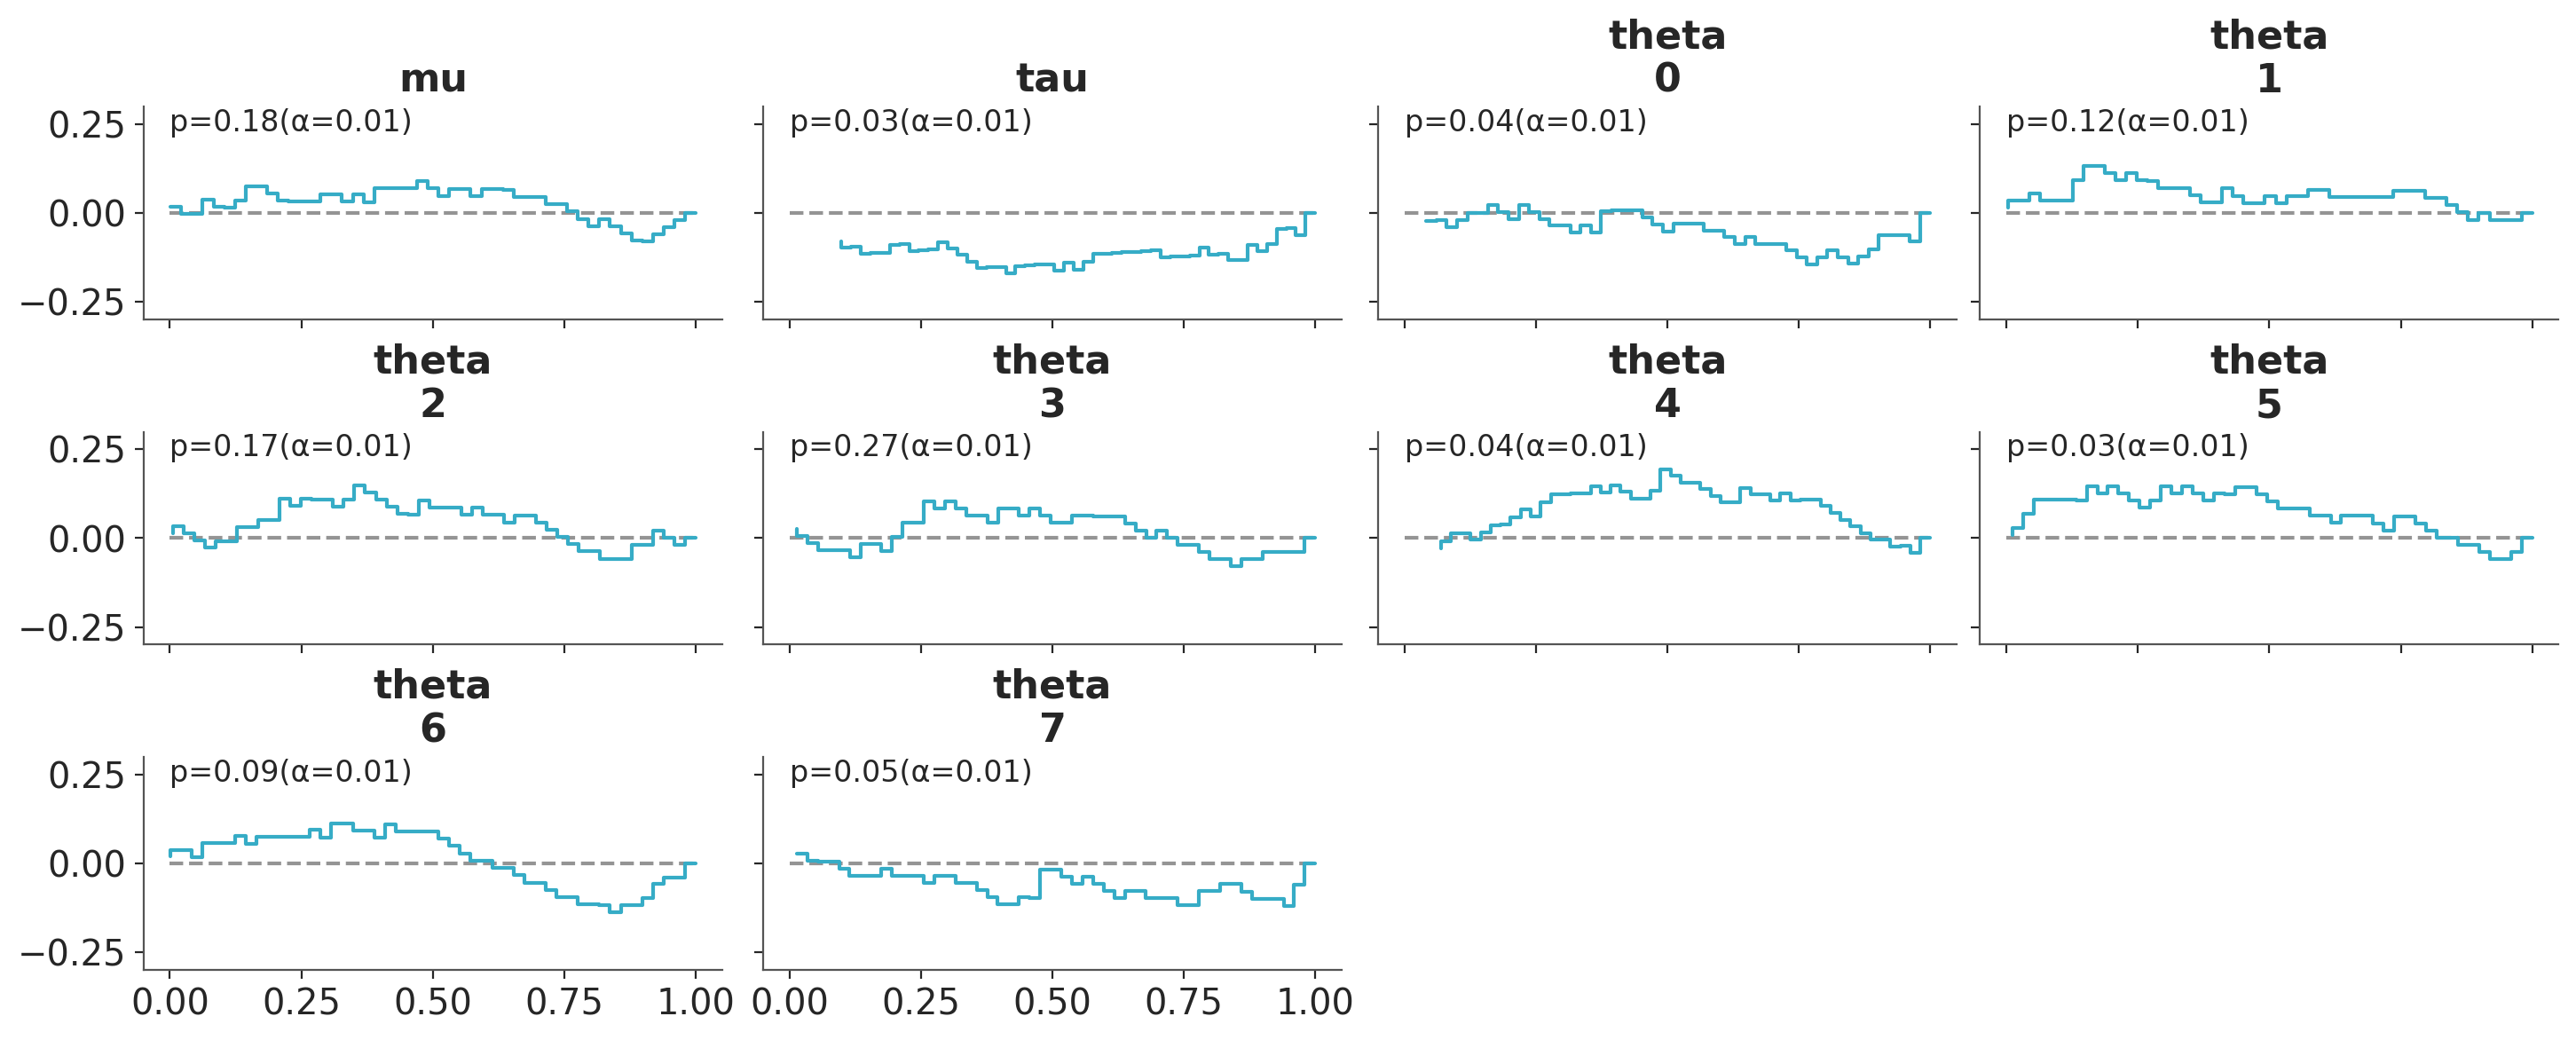

In [7]:
plot_ecdf_pit(sbc.simulations,
              group="posterior_sbc",
              visuals={"xlabel": False},
);

## Intentionally Skewing the Augmented Posterior Using Custom augmentation with `augment_observed`

We intentionally skew the augmented posterior by keeping only 1 of the original observations and concatenating them with the replicated data. This creates a mismatch between the reference draw (which is based on the full observed data) and the augmented posterior (which is based on a subset of the observed data), leading to skewed rank statistics.

In [4]:
def augment_observed(model, observed_data, replicated_data, simulation_idx):
    """Keep only the last 25 original observations + replicated."""
    data = {"y": np.concatenate([observed_data["y"].values[-1:], replicated_data["y"]])}
    return data


def update_data(model, augmented_data, simulation_idx):
    with model:
        pm.set_data(
            new_data={
                "sigma": np.concatenate(
                    [model["sigma"].get_value()[-1:], model["sigma"].get_value()]
                ),
                "school_idx": np.concatenate(
                    [model["school_idx"].get_value()[-1:], model["school_idx"].get_value()]
                ),
            },
            coords={"obs": np.arange(8 + 1)},
        )

skewed_sbc = simuk.SBC(
    centered_eight,
    method="posterior",
    trace=trace,
    augment_observed=augment_observed,
    update_data=update_data,
    num_simulations=50,
    sample_kwargs={"chains": 4, "draws": 50, "tune": 50},
    progress_bar=False,
)

skewed_sbc.run_simulations()

### Visualize the skewed results and and Replot the Original Simulations using `compute_rank_statistics`

The results indicate a clear deviation from uniformity, with the ECDF lines falling outside the credible interval, as indicated by the red points. This suggests that the self-consistency property of Bayesian updating does not hold.

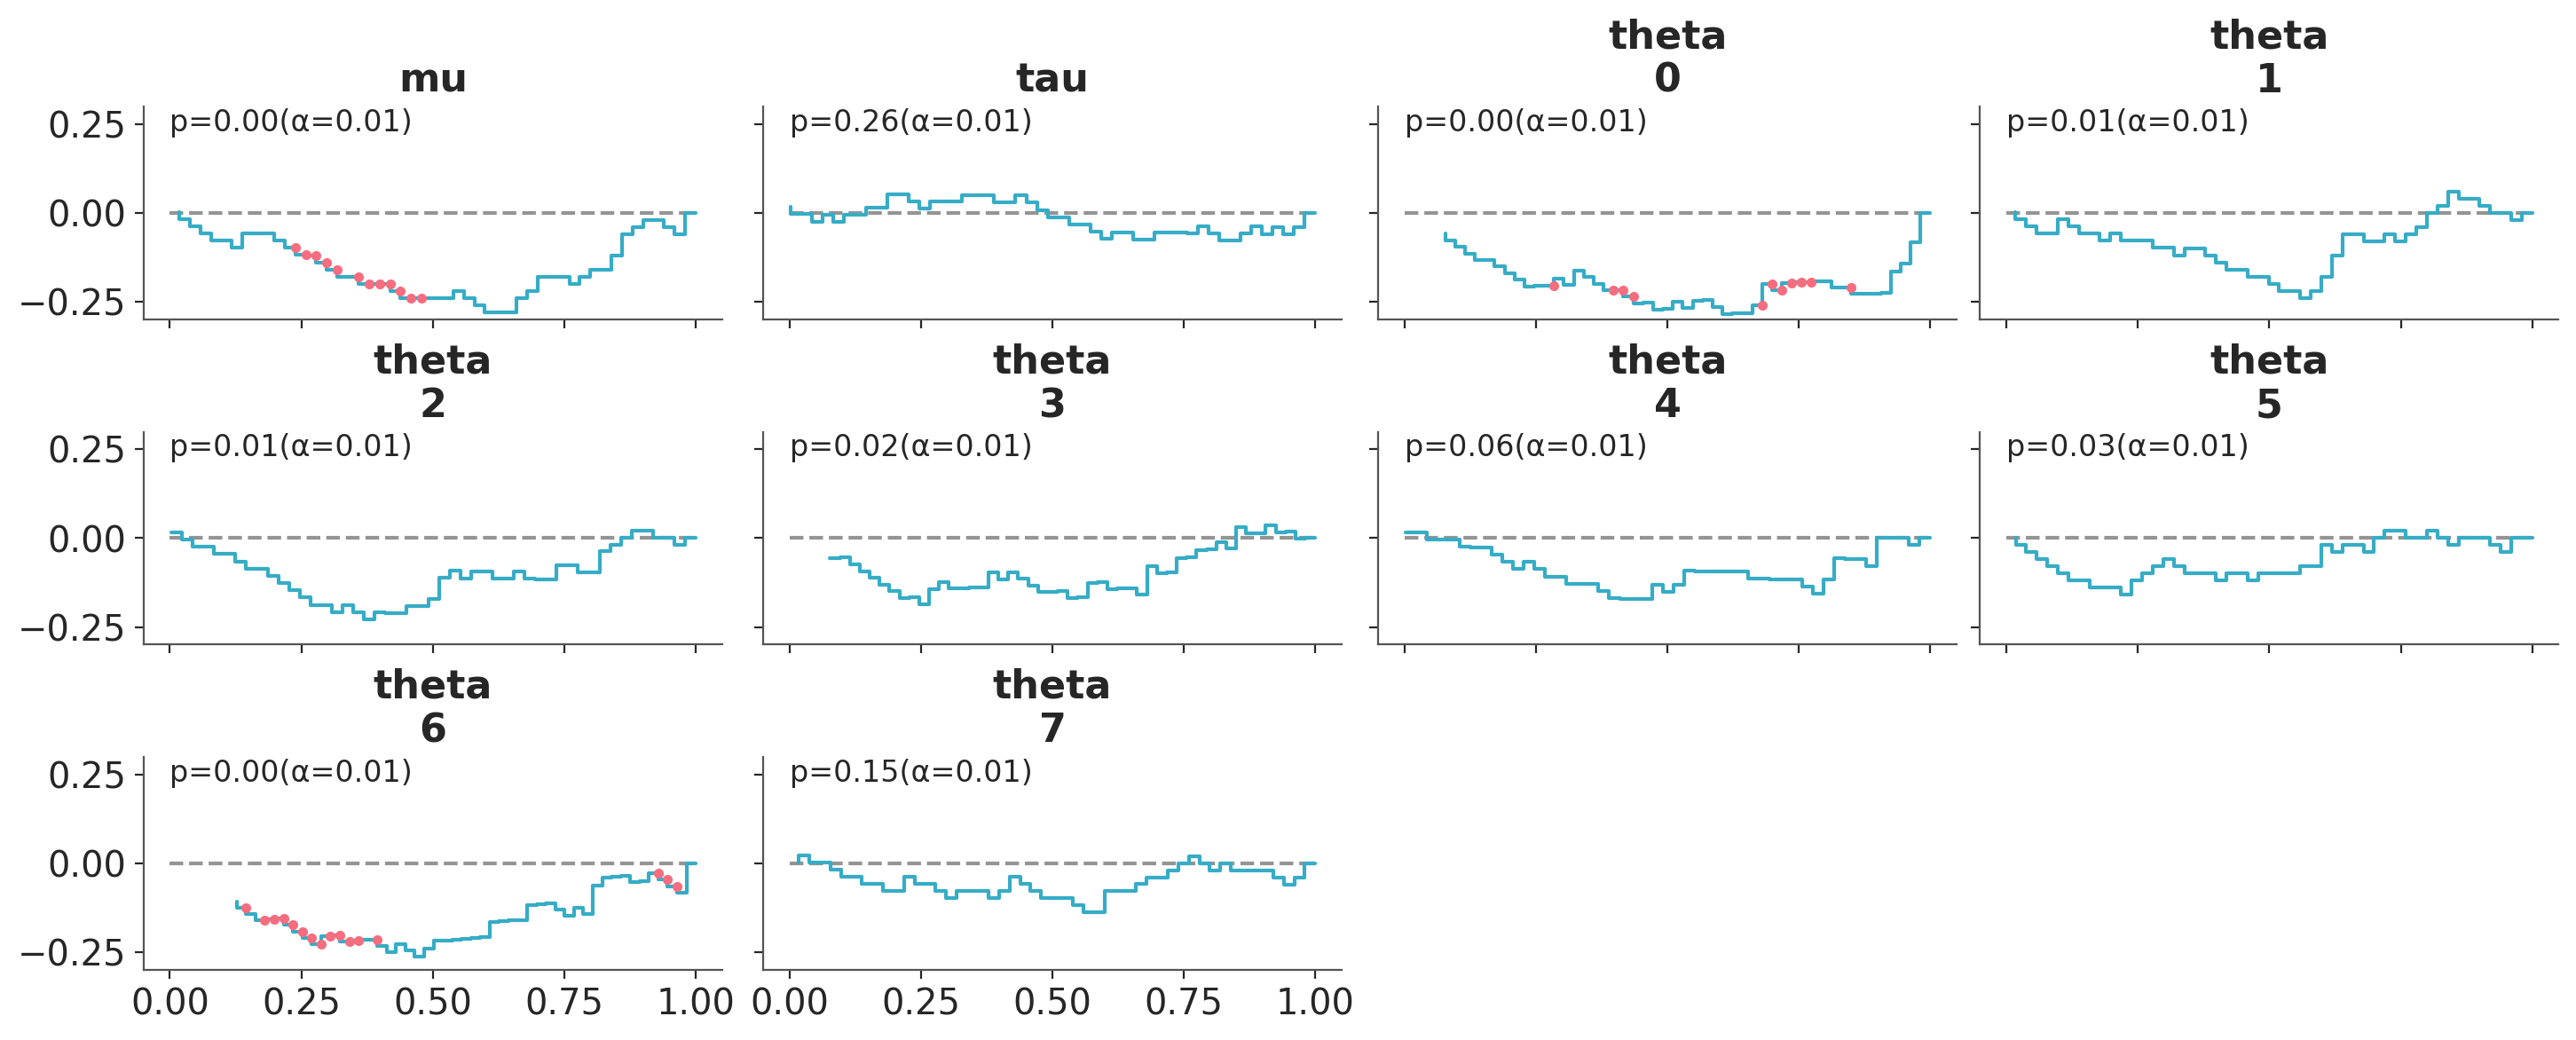

In [5]:
plot_ecdf_pit(skewed_sbc.simulations, group="posterior_sbc", visuals={"xlabel": False})

We shall also replot the original Posterior SBC results using the same quantity using `compute_rank_statistics`. This allows us to compare the results without need to re-run the simulations.

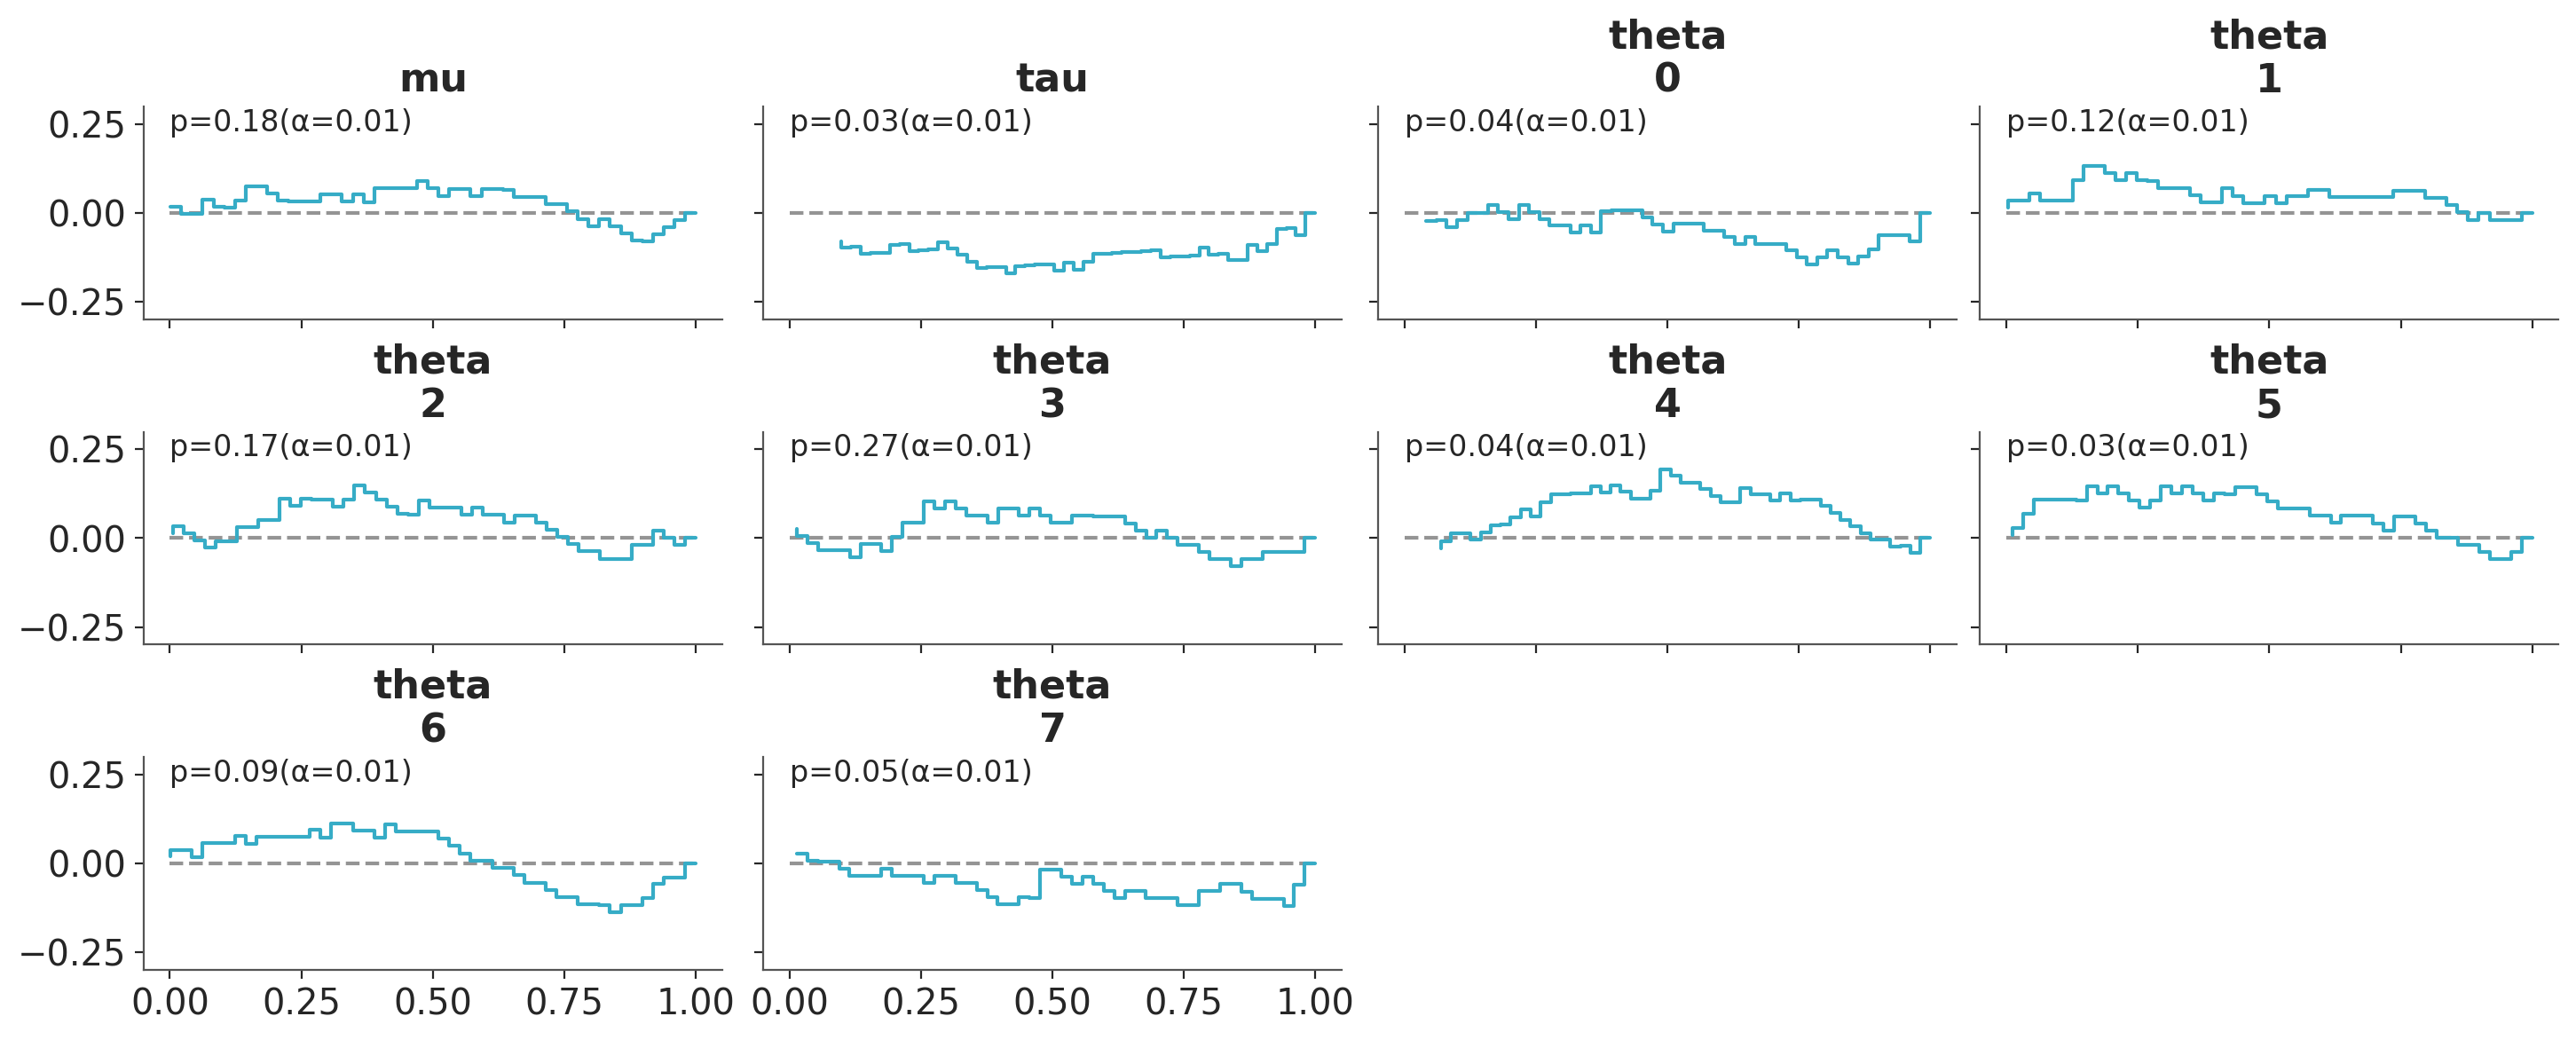

In [1]:
sbc.compute_rank_statistics(lambda _, param_value: param_value)
plot_ecdf_pit(sbc.simulations, group="posterior_sbc", visuals={"xlabel": False})

## References

- Säilynoja, T., Schmitt, M., Bürkner, P.-C., & Vehtari, A. (2025).
  *Posterior SBC: Simulation-Based Calibration Checking Conditional on Data*.
  [arXiv:2502.03279](https://arxiv.org/abs/2502.03279)
- Talts, S., Betancourt, M., Simpson, D., Vehtari, A., & Gelman, A. (2020).
  *Validating Bayesian Inference Algorithms with Simulation-Based Calibration*.
  [arXiv:1804.06788](https://arxiv.org/abs/1804.06788)